
# Predicting Sleep Quality

## 1. Setup and Data Loading

In [52]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Loading data...")
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
df.head()


Loading data...


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 2. Target Definition and Feature Selection
- Our target variable is **Quality of Sleep** (1–10).
- We drop identifiers and string fields that are hard to use numerically (like blood pressure).
- Categorical variables are encoded using one-hot encoding.

In [53]:
# Basic cleaning for Sleep Disorder to handle "None"/missing
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")
df["Sleep Disorder"] = df["Sleep Disorder"].replace({
    "none": "None",
    "NONE": "None",
    "": "None"
})

# Combine Normal BMI Group
df["BMI Category"] = df["BMI Category"].replace({
    "Normal Weight": "Normal"
})

# Remove Occupation with < 10 samples
min_count = 10
valid_occ = df['Occupation'].value_counts()
valid_occ = valid_occ[valid_occ >= min_count].index
df = df[df['Occupation'].isin(valid_occ)]

# Define target and features
target_col = "Quality of Sleep"

drop_cols = [
    "Person ID",
    "Blood Pressure"   # we drop this instead of trying to parse "120/80"
]

# Keep all remaining columns except target + drops
feature_cols = [c for c in df.columns if c not in drop_cols + [target_col]]

X = df[feature_cols].copy()
y = df[target_col].astype(float)

# Identify numeric and categorical columns
numeric_features = [
    "Age",
    "Sleep Duration",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

categorical_features = [
    col for col in feature_cols
    if col not in numeric_features
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['Age', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']
Categorical features: ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']


## 3. Train–Test Split and Preprocessing Pipeline
- We split the data into training and test sets.
- For numeric features, we apply standardization.
- For categorical features, we apply one-hot encoding.
- This preprocessing is shared across all models using a `ColumnTransformer`.

In [54]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)



## 4. Models to Compare
 - **DummyRegressor**: baseline that always predicts the mean
 - **Ridge Regression**: linear model with L2 regularization
 - **Random Forest Regressor**
 - **Gradient Boosting Regressor**
 - **MLPRegressor**: a simple feed-forward neural network


In [ ]:

models = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "Neural Net (MLP)": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-3,
        learning_rate_init=1e-3,
        max_iter=300,
        random_state=42
    )
}

pipelines = {
    name: Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}


## 5. Training and Evaluation
### For each model, we:
- 1. Fit on the training data.
- 2. Predict on the test data.
- 3. Compute **MAE**, **RMSE**, and **R²**.


In [56]:
results = []

for name, pipe in pipelines.items():
    print(f"Training {name}...")

    # Fit model
    pipe.fit(X_train, y_train)

    # Predict
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values(by="MAE")
results_df


Training Dummy (Mean)...
Training Ridge...
Training Random Forest...
Training Gradient Boosting...
Training Neural Net (MLP)...


,Model,MAE,RMSE,R2
3,Gradient Boosting,0.012510,0.059112,0.997077
2,Random Forest,0.026712,0.088853,0.993395
4,Neural Net (MLP),0.141017,0.338040,0.904404
1,Ridge,0.147607,0.243185,0.950526
0,Dummy (Mean),0.946386,1.093530,-0.000386


C:\Users\chen-\AppData\Local\Temp\ipykernel_5272\1566506997.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], data=results_df, x="Model", y=metric, palette="Set2")
C:\Users\chen-\AppData\Local\Temp\ipykernel_5272\1566506997.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(results_df["Model"], rotation=45)
C:\Users\chen-\AppData\Local\Temp\ipykernel_5272\1566506997.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], data=results_df, x="Model", y=metric, palette="Set2")
C:\Users\chen-\AppData\Local\Temp\ipykernel_5272\1566506997.py:9: UserWarning: set_tickl

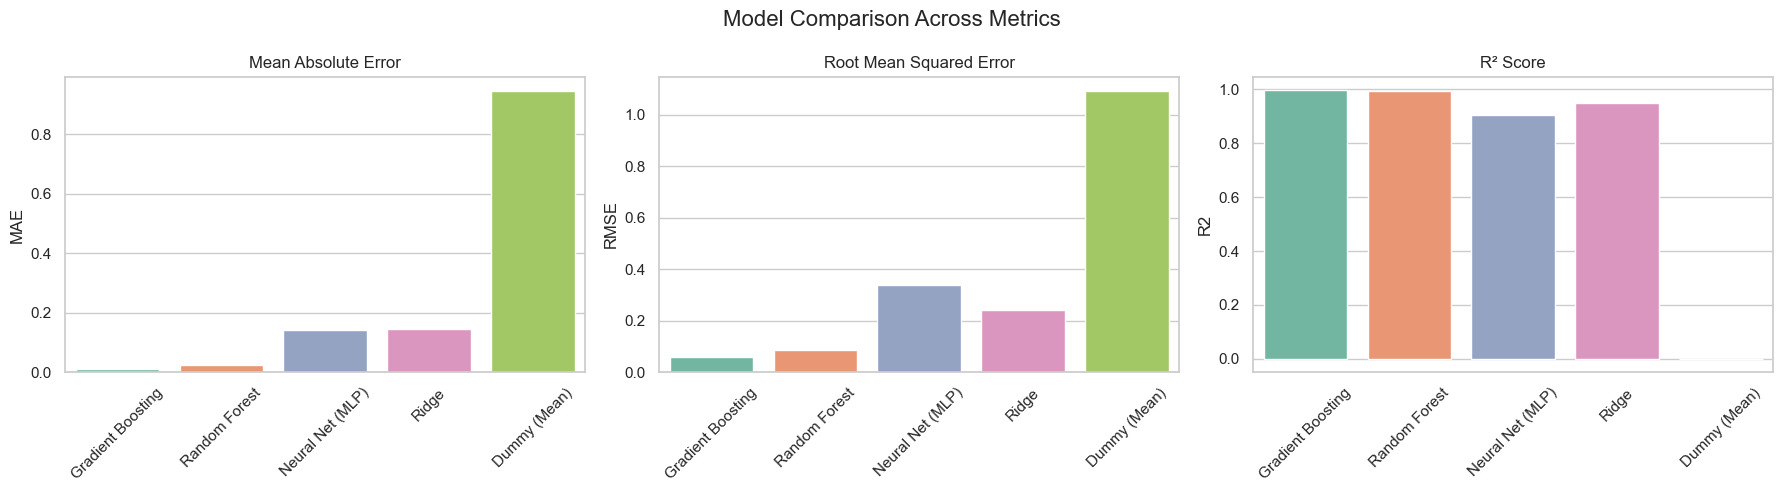

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ["MAE", "RMSE", "R2"]
titles  = ["Mean Absolute Error", "Root Mean Squared Error", "R² Score"]

for i, metric in enumerate(metrics):
    sns.barplot(ax=axes[i], data=results_df, x="Model", y=metric, palette="Set2")
    axes[i].set_title(titles[i])
    axes[i].set_xticklabels(results_df["Model"], rotation=45)
    axes[i].set_xlabel("")
    
plt.suptitle("Model Comparison Across Metrics", fontsize=16)
plt.tight_layout()
plt.show()


## 6. Cross-Validation

In [58]:
cv_results = []

for name, pipe in pipelines.items():
    print(f"Cross-validating {name}...")
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    cv_results.append({
        "Model": name,
        "CV_MAE_mean": -scores.mean(),
        "CV_MAE_std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV_MAE_mean")
cv_results_df


Cross-validating Dummy (Mean)...
Cross-validating Ridge...
Cross-validating Random Forest...
Cross-validating Gradient Boosting...
Cross-validating Neural Net (MLP)...


,Model,CV_MAE_mean,CV_MAE_std
3,Gradient Boosting,0.050223,0.026031
2,Random Forest,0.059667,0.026096
4,Neural Net (MLP),0.122602,0.023765
1,Ridge,0.135018,0.017132
0,Dummy (Mean),1.031837,0.052448


## 7. Inspect the Best Model
### We can pick the best performing model based on MAE/RMSE/R² and the cross-validation results.

Best model based on true test MAE: Gradient Boosting


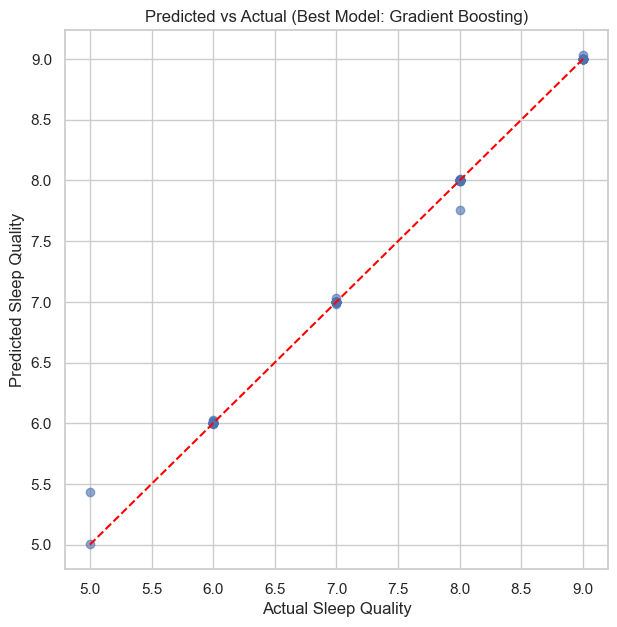

In [59]:
# Choose best by lowest MAE on test set
best_model_name = results_df.iloc[0]["Model"]
print("Best model based on true test MAE:", best_model_name)

best_pipeline = pipelines[best_model_name]
best_pipeline.fit(X_train, y_train)

# Predict with the real best model
y_pred_best = best_pipeline.predict(X_test)

# Visualization
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         ls="--", color="red")
plt.xlabel("Actual Sleep Quality")
plt.ylabel("Predicted Sleep Quality")
plt.title(f"Predicted vs Actual (Best Model: {best_model_name})")
plt.show()

### Confusion Matrix

<Figure size 1000x800 with 0 Axes>

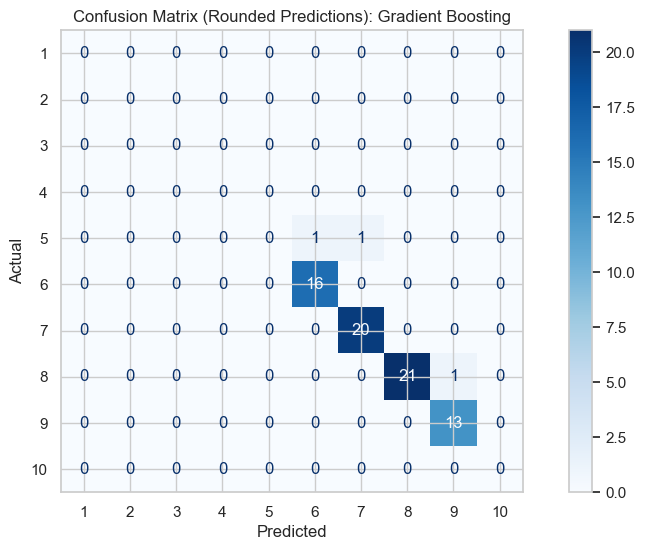

In [60]:
y_true_cls = np.round(y_test).astype(int)
y_pred_cls = np.round(y_pred).astype(int)

# Bound results to valid range (e.g., 1–10)
y_true_cls = np.clip(y_true_cls, 1, 10)
y_pred_cls = np.clip(y_pred_cls, 1, 10)

# Compute confusion matrix
cm = confusion_matrix(y_true_cls, y_pred_cls, labels=range(1, 11))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(1, 11))
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix (Rounded Predictions): {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 8. Saving the Trained Models

In [61]:
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

for name, pipe in pipelines.items():
    filename = f"saved_models/{name.replace(' ', '_').lower()}.joblib"
    joblib.dump(pipe, filename)
    print(f"Saved: {filename}")

Saved: saved_models/dummy_(mean).joblib
Saved: saved_models/ridge.joblib
Saved: saved_models/random_forest.joblib
Saved: saved_models/gradient_boosting.joblib
Saved: saved_models/neural_net_(mlp).joblib
